# **Question 1: Which items are running out of stock right now?**

Active, non-discontinued products like Gorgonzola Telino and Sir Rodney's

*   Active, non-discontinued products like Gorgonzola Telino and Sir Rodney's
Scones have hit or fallen below their required reorder levels, with items like Gorgonzola Telino sitting at zero units available on shelves.

# **Question 2: What are our top-selling products versus how many we have left?**

Merging transaction volume with inventory reveals a supply mismatch: several of your top 10 best-selling products have critically low inventory levels relative to their total sales volume.   

# **Question 3: Which suppliers/carriers take the longest to ship orders?**

Shipping lead times differ notably across fulfillment partners: Federal Shipping is the fastest carrier averaging ~7.5 days, while United Package takes the longest at over 9.2 days.   

Hypotheses & Next Steps

# **Hypothesis 1**

Reorder triggers are taking too long to execute, or safety stock thresholds (ReorderLevel) were calculated based on static averages that no longer match current order volume.

Action: Immediately place stock replenishment orders for all non-discontinued items where UnitsInStock <= ReorderLevel to prevent stockouts and lost revenue.   

# **Hypothesis 2**

Popular items generate high sales velocity, but because inventory management isn't dynamically linked to real-time sales rates, high-demand items are at constant risk of sudden stockouts.

Action: Prioritize inventory replenishment based on sales velocity (total units sold) rather than relying solely on static reorder flags.

# **Hypothesis 3**

Assigning orders to slower carriers like United Package increases overall customer lead times and creates delivery bottlenecks, especially for urgent or high-volume orders.

Action: Shift high-priority or best-selling product orders to Federal Shipping to minimize transit times, and re-evaluate service contracts with United Package.

### Questions to ask:
# 1. Which items are running out of stock right now?
**Plain English Question**: Which products have almost zero units left on the shelf?

Tables Needed: products

# 2. What are our top-selling products versus how many we have left?
**Plain English Question**: Are our most popular products in danger of selling out soon?

Tables Needed: order_details and products

# 3. Which suppliers take the longest to ship orders?
**Plain English Question**: How many days does it take for each supplier to actually ship out our goods?

Tables Needed: orders

In [ ]:
#importing libraries
import sqlite3
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ***Project Checklist***

Data Cleaning
Check missing values (df.isnull().sum())

Convert date text to datetime (pd.to_datetime())

Question 1: Low Stock Items
Filter df_products for active items with low stock

Plot a bar chart of the lowest-stock products

Question 2: Popularity vs. Stock
Merge df_order_details and df_products

Sum sales per product and compare to current stock

Plot the top 10 best sellers alongside their stock left

Question 3: Shipping Times
Subtract OrderDate from ShippedDate to get delivery days

Calculate average shipping days per company

Plot a bar chart from fastest to slowest

In [ ]:
northwind = {
    'categories': pd.read_csv("categories.csv"),
    'customers': pd.read_csv("customers.csv"),
    'employee_territory': pd.read_csv("employee_territory.csv"),
    'employees': pd.read_csv("employees.csv"),
    'order_details': pd.read_csv("order_details.csv"),
    'orders': pd.read_csv("orders.csv"),
    'products': pd.read_csv("products.csv"),
    'region': pd.read_csv("region.csv"),
    'shippers': pd.read_csv("shippers.csv"),
    'suppliers': pd.read_csv("suppliers.csv"),
    'territories': pd.read_csv("territories.csv")

}

In [ ]:
df_categories = northwind['categories']
df_customers = northwind['customers']
df_employee_territory = northwind['employee_territory']
df_order_details = northwind['order_details']
df_orders = northwind['orders']
df_products = northwind['products']
df_region = northwind['region']
df_shippers = northwind['shippers']
df_suppliers = northwind['suppliers']
df_territories = northwind['territories']

In [ ]:
#INSPECTING SOME OF THE DATA

In [ ]:
df_categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CategoryID    8 non-null      int64 
 1   CategoryName  8 non-null      object
 2   Description   8 non-null      object
dtypes: int64(1), object(2)
memory usage: 324.0+ bytes


In [ ]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ProductID        77 non-null     int64  
 1   ProductName      77 non-null     object 
 2   SupplierID       77 non-null     int64  
 3   CategoryID       77 non-null     int64  
 4   QuantityPerUnit  77 non-null     object 
 5   UnitPrice        77 non-null     float64
 6   UnitsInStock     77 non-null     int64  
 7   UnitsOnOrder     77 non-null     int64  
 8   ReorderLevel     77 non-null     int64  
 9   Discontinued     77 non-null     int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 6.1+ KB


In [ ]:
df_products.describe()

,ProductID,SupplierID,CategoryID,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,39.000000,13.649351,4.116883,28.866364,40.506494,10.129870,12.467532,0.103896
std,22.371857,8.220267,2.395028,33.815111,36.147222,23.141072,10.931105,0.307127
min,1.000000,1.000000,1.000000,2.500000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,7.000000,2.000000,13.250000,15.000000,0.000000,0.000000,0.000000
50%,39.000000,13.000000,4.000000,19.500000,26.000000,0.000000,10.000000,0.000000
75%,58.000000,20.000000,6.000000,33.250000,61.000000,0.000000,25.000000,0.000000
max,77.000000,29.000000,8.000000,263.500000,125.000000,100.000000,30.000000,1.000000


In [ ]:
df_products.isna().sum()

,0
ProductID,0
ProductName,0
SupplierID,0
CategoryID,0
QuantityPerUnit,0
UnitPrice,0
UnitsInStock,0
UnitsOnOrder,0
ReorderLevel,0
Discontinued,0


In [ ]:
df_categories.info()
df_categories.describe()
df_categories.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CategoryID    8 non-null      int64 
 1   CategoryName  8 non-null      object
 2   Description   8 non-null      object
dtypes: int64(1), object(2)
memory usage: 324.0+ bytes


,0
CategoryID,0
CategoryName,0
Description,0


In [ ]:
df_categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CategoryID    8 non-null      int64 
 1   CategoryName  8 non-null      object
 2   Description   8 non-null      object
dtypes: int64(1), object(2)
memory usage: 324.0+ bytes


In [ ]:
df_categories.describe()

,CategoryID
count,8.00000
mean,4.50000
std,2.44949
min,1.00000
25%,2.75000
50%,4.50000
75%,6.25000
max,8.00000


In [ ]:
df_categories.isna().sum()

,0
CategoryID,0
CategoryName,0
Description,0


In [ ]:
#Convert date text to datetime (pd.to_datetime())

In [ ]:
pd.to_datetime(df_orders["OrderDate"])

,OrderDate
0,1996-07-04
1,1996-07-05
2,1996-07-08
3,1996-07-08
4,1996-07-09
...,...
825,1998-05-05
826,1998-05-06
827,1998-05-06
828,1998-05-06


In [ ]:
pd.to_datetime(df_orders["RequiredDate"])

,RequiredDate
0,1996-08-01
1,1996-08-16
2,1996-08-05
3,1996-08-05
4,1996-08-06
...,...
825,1998-06-02
826,1998-06-03
827,1998-06-03
828,1998-06-03


In [ ]:
pd.to_datetime(df_orders["ShippedDate"], errors='coerce')

,ShippedDate
0,1996-07-16
1,1996-07-10
2,1996-07-12
3,1996-07-15
4,1996-07-11
...,...
825,NaT
826,NaT
827,NaT
828,NaT


In [ ]:
#Question 1: Low Stock Items Filter df_products for active items with low stock

#Plot a bar chart of the lowest-stock products

In [ ]:
df_products.isna().sum()

,0
ProductID,0
ProductName,0
SupplierID,0
CategoryID,0
QuantityPerUnit,0
UnitPrice,0
UnitsInStock,0
UnitsOnOrder,0
ReorderLevel,0
Discontinued,0


In [ ]:
low_stock_df = df_products[(df_products['Discontinued'] == 0) & (df_products['UnitsInStock'] == 0)]

In [ ]:
low_stock_sorted = low_stock_df.sort_values(by='UnitsInStock', ascending=True)

In [ ]:
print(low_stock_sorted)

    ProductID        ProductName  SupplierID  CategoryID  QuantityPerUnit  \
30         31  Gorgonzola Telino          14           4  12 - 100 g pkgs   

    UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  Discontinued  
30       12.5             0            70            20             0  


In [ ]:
low_stock_sorted

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
30,31,Gorgonzola Telino,14,4,12 - 100 g pkgs,12.5,0,70,20,0


In [ ]:
# Show only the product name and current stock
low_stock_sorted[['ProductName', 'UnitsInStock', 'ReorderLevel']]

,ProductName,UnitsInStock,ReorderLevel
30,Gorgonzola Telino,0,20


# **VISUALIZATION IN SEABORN**

In [ ]:
#SETTING CHART SIZE
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='UnitsInStock', ylabel='ProductName'>

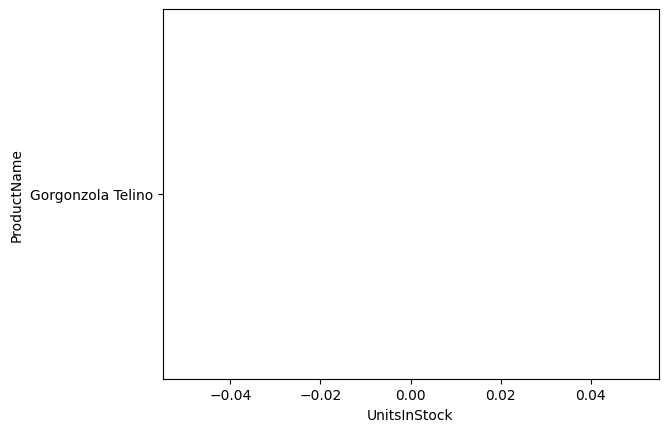

In [ ]:
sns.barplot(data=low_stock_sorted, x='UnitsInStock', y='ProductName')

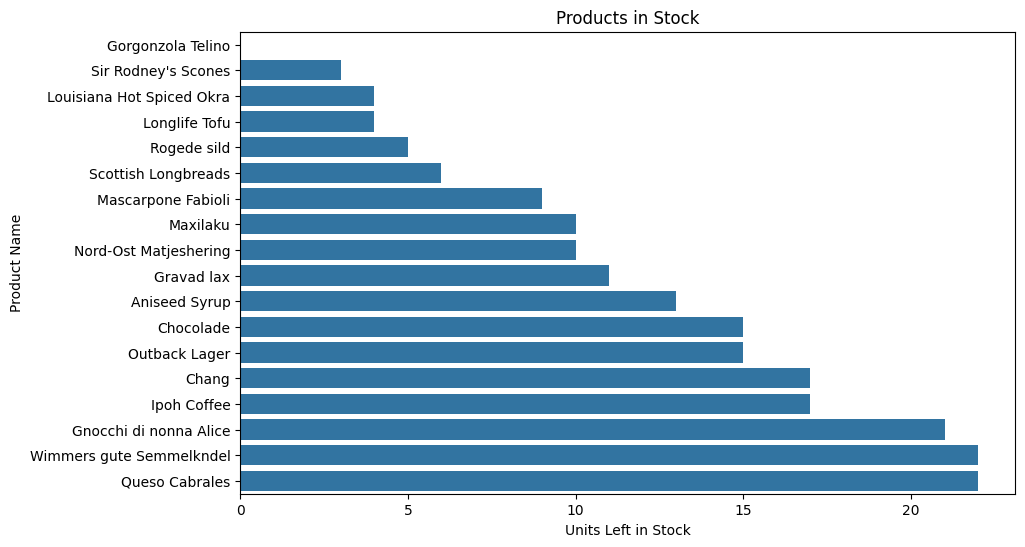

In [ ]:
# 1. Filter and sort
low_stock_df = df_products[(df_products['Discontinued'] == 0) & (df_products['UnitsInStock'] <= df_products['ReorderLevel'])]
low_stock_sorted = low_stock_df.sort_values(by='UnitsInStock', ascending=True)

# 2. Build the chart in the SAME cell
plt.figure(figsize=(10, 6))
sns.barplot(data=low_stock_sorted, x='UnitsInStock', y='ProductName')

plt.title('Products in Stock')
plt.xlabel('Units Left in Stock')
plt.ylabel('Product Name')

plt.show()

In [ ]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderID         830 non-null    int64  
 1   CustomerID      830 non-null    object 
 2   EmployeeID      830 non-null    int64  
 3   OrderDate       830 non-null    object 
 4   RequiredDate    830 non-null    object 
 5   ShippedDate     809 non-null    object 
 6   ShipVia         830 non-null    int64  
 7   Freight         830 non-null    float64
 8   ShipName        830 non-null    object 
 9   ShipAddress     830 non-null    object 
 10  ShipCity        830 non-null    object 
 11  ShipRegion      323 non-null    object 
 12  ShipPostalCode  811 non-null    object 
 13  ShipCountry     830 non-null    object 
dtypes: float64(1), int64(3), object(10)
memory usage: 90.9+ KB


In [ ]:
df_orders.describe()

,OrderID,EmployeeID,ShipVia,Freight
count,830.000000,830.000000,830.000000,830.000000
mean,10662.500000,4.403614,2.007229,78.244205
std,239.744656,2.499648,0.779685,116.779294
min,10248.000000,1.000000,1.000000,0.020000
25%,10455.250000,2.000000,1.000000,13.380000
50%,10662.500000,4.000000,2.000000,41.360000
75%,10869.750000,7.000000,3.000000,91.430000
max,11077.000000,9.000000,3.000000,1007.640000


In [ ]:
#CHECKING MISSING VALUES
df_orders.isna().sum()

,0
OrderID,0
CustomerID,0
EmployeeID,0
OrderDate,0
RequiredDate,0
ShippedDate,21
ShipVia,0
Freight,0
ShipName,0
ShipAddress,0


In [ ]:
#FILLING MISSING VALUES
df_orders["ShipRegion"] = df_orders["ShipRegion"].fillna('unknown')
df_orders["ShipPostalCode"] = df_orders["ShipPostalCode"].fillna('unknown')
df_orders["ShippedDate"] = df_orders["ShippedDate"].fillna('unknown')

In [ ]:
#CHECKING MISSING VALUES
df_orders.isna().sum()

,0
OrderID,0
CustomerID,0
EmployeeID,0
OrderDate,0
RequiredDate,0
ShippedDate,0
ShipVia,0
Freight,0
ShipName,0
ShipAddress,0


In [ ]:
print(df_orders["ShipRegion"])

0      unknown
1      unknown
2           RJ
3      unknown
4      unknown
        ...   
825    unknown
826    unknown
827    unknown
828    unknown
829         NM
Name: ShipRegion, Length: 830, dtype: object


In [ ]:
df_orders.drop_duplicates()

,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,ShipAddress,ShipCity,ShipRegion,ShipPostalCode,ShipCountry
0,10248,VINET,5,1996-07-04 00:00:00,1996-08-01 00:00:00,1996-07-16 00:00:00,3,32.38,Vins et alcools Chevalier,59 rue de l-Abbaye,Reims,unknown,51100,France
1,10249,TOMSP,6,1996-07-05 00:00:00,1996-08-16 00:00:00,1996-07-10 00:00:00,1,11.61,Toms Spezialitten,Luisenstr. 48,Mnster,unknown,44087,Germany
2,10250,HANAR,4,1996-07-08 00:00:00,1996-08-05 00:00:00,1996-07-12 00:00:00,2,65.83,Hanari Carnes,"Rua do Pao, 67",Rio de Janeiro,RJ,05454-876,Brazil
3,10251,VICTE,3,1996-07-08 00:00:00,1996-08-05 00:00:00,1996-07-15 00:00:00,1,41.34,Victuailles en stock,"2, rue du Commerce",Lyon,unknown,69004,France
4,10252,SUPRD,4,1996-07-09 00:00:00,1996-08-06 00:00:00,1996-07-11 00:00:00,2,51.30,Suprmes dlices,"Boulevard Tirou, 255",Charleroi,unknown,B-6000,Belgium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,11073,PERIC,2,1998-05-05 00:00:00,1998-06-02 00:00:00,unknown,2,24.95,Pericles Comidas clsicas,Calle Dr. Jorge Cash 321,Mxico D.F.,unknown,5033,Mexico
826,11074,SIMOB,7,1998-05-06 00:00:00,1998-06-03 00:00:00,unknown,2,18.44,Simons bistro,Vinbltet 34,Kobenhavn,unknown,1734,Denmark
827,11075,RICSU,8,1998-05-06 00:00:00,1998-06-03 00:00:00,unknown,2,6.19,Richter Supermarkt,Starenweg 5,Genve,unknown,1204,Switzerland
828,11076,BONAP,4,1998-05-06 00:00:00,1998-06-03 00:00:00,unknown,2,38.28,Bon app-,"12, rue des Bouchers",Marseille,unknown,13008,France


In [ ]:
# df_orders date columns
# OrderDate	0
#RequiredDate	0
#ShippedDate

In [ ]:
#Question 1: Low Stock Items Filter df_products for active items with low stock
#Plot a bar chart of the lowest-stock products


In [ ]:
df_merged = pd.merge(df_order_details, df_products, on='ProductID')

In [ ]:
sales_by_product = df_merged.groupby('ProductName')['Quantity'].sum().reset_index()

In [ ]:
product_summary = df_merged.groupby(['ProductName', 'UnitsInStock'])['Quantity'].sum().reset_index()

In [ ]:
product_summary = product_summary.rename(columns={'Quantity': 'TotalSold'})

In [ ]:
top_sellers = product_summary.sort_values(by='TotalSold', ascending=False).head(10)

In [ ]:
#1. Filter and sort

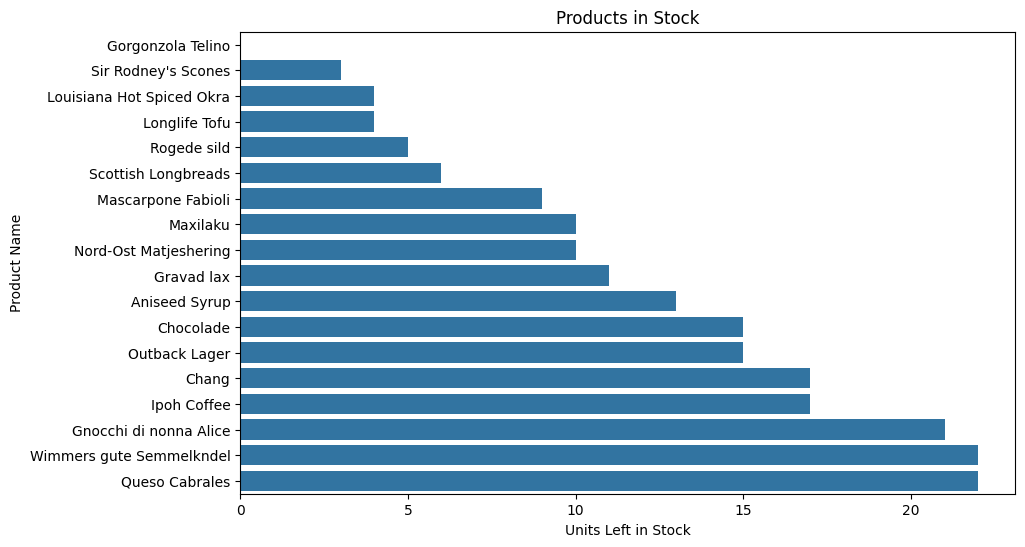

In [ ]:
#1. Filter and sort
low_stock_df = df_products[(df_products['Discontinued'] == 0) & (df_products['UnitsInStock'] <= df_products['ReorderLevel'])]
low_stock_sorted = low_stock_df.sort_values(by='UnitsInStock', ascending=True)

#Build the chart in the SAME cell
plt.figure(figsize=(10, 6))
sns.barplot(data=low_stock_sorted, x='UnitsInStock', y='ProductName')

plt.title('Products in Stock')
plt.xlabel('Units Left in Stock')
plt.ylabel('Product Name')

plt.show()

In [ ]:
# Build the chart in the SAME cell

# **DATAFRAMES**

df_categories

df_customers

df_employee_territory

df_order_details

df_orders

df_products

df_region

df_shippers

df_suppliers

df_territories

In [ ]:
#Question 2: Popularity vs. Stock Merge df_order_details and df_products

#Sum sales per product and compare to current stock

In [ ]:
#step 1
df_merged = pd.merge(df_order_details, df_products, on='ProductID')

In [ ]:
#Step 2:
#Sum Total Sales Volume per Product Group the merged dataset by product to calculate the total quantity ordered across all transactions.

#Concept: Use .groupby() on ProductName and .sum() the Quantity column. Reset the index so it remains a standard DataFrame.


sales_by_product = df_merged.groupby('ProductName')['Quantity'].sum().reset_index()



In [ ]:
#Step 3:#
#Bring Stock Levels Back into the Summary Merge the total sales summary back with df_products (or include UnitsInStock during your initial grouping) so you can directly compare total units sold against current stock.

#Concept: Group by both ProductName and UnitsInStock simultaneously:

product_stock_summary = df_merged.groupby(['ProductName', 'UnitsInStock'])['Quantity'].sum().reset_index()


In [ ]:
#Step 4:
#Sort to Find the Top Sellers Sort the final table by TotalSold(Quantity) in descending order to surface your top-performing items.

top_selling_products = product_stock_summary.sort_values(by='Quantity', ascending=False).head(10)



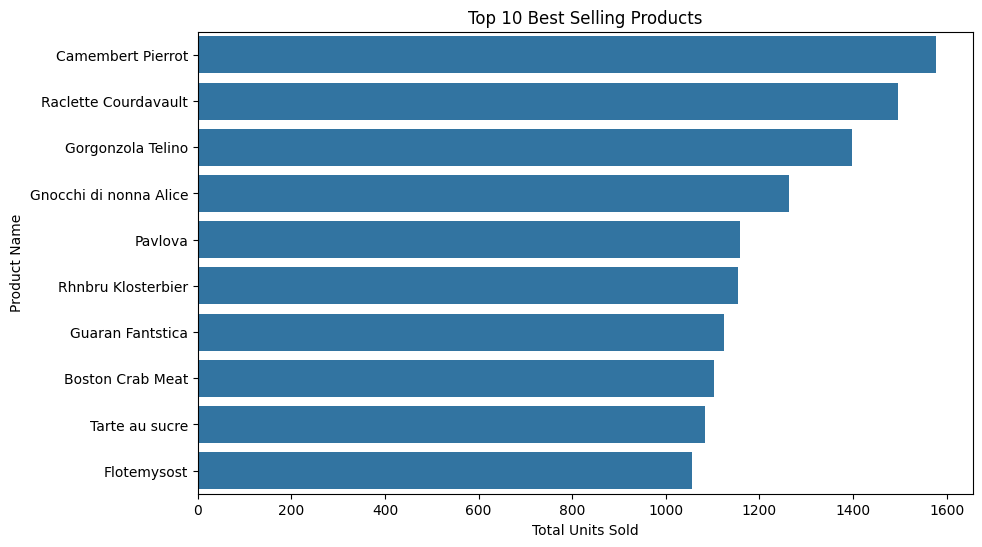

In [ ]:
#Step 5:
#Visualize (Top 10 Best Sellers vs. Stock Left)
#Create a side-by-side or stacked bar chart to visualize sales volume right next to current warehouse inventory.

#Hint for Seaborn: Melt the DataFrame so TotalSold and UnitsInStock exist in a single column for easy plotting, or plot a simple horizontal bar chart showing top sales with stock numbers overlaid/compared.

plt.figure(figsize=(10, 6))

# Plot top 10 products by total units sold
sns.barplot(data=top_selling_products, x='Quantity', y='ProductName')

plt.title('Top 10 Best Selling Products')
plt.xlabel('Total Units Sold')
plt.ylabel('Product Name')

plt.show()

In [ ]:
#-------------------

In [ ]:
#Question 3: Shipping Times Subtract OrderDate from ShippedDate to get delivery days

#Calculate average shipping days per company

#Plot a bar chart from fastest to slowest




In [ ]:
#Step 1: Calculate Shipping Lead Time (in Days)
#Subtract OrderDate from ShippedDate inside df_orders. Because both columns are formatted as datetime, subtracting them yields a time duration (a timedelta object). Using .dt.days converts that duration into a clean integer number of days.
# 1. Convert date columns to proper datetime format (saving them back to df_orders)
df_orders['OrderDate'] = pd.to_datetime(df_orders['OrderDate'], errors='coerce')
df_orders['ShippedDate'] = pd.to_datetime(df_orders['ShippedDate'], errors='coerce')

# 2. Calculate shipping lead time in days
df_orders['ShippingDays'] = (df_orders['ShippedDate'] - df_orders['OrderDate']).dt.days


In [ ]:
#Step 2: Merge with df_shippers
#df_orders contains a ShipVia column, which corresponds to the ShipperID in df_shippers. Merge them so you can see actual company names (like Speedy Express or United Package) instead of numeric IDs.

#Code Structure:

df_shipping_summary = pd.merge(df_orders, df_shippers, left_on='ShipVia', right_on='ShipperID')

In [ ]:
#Step 3: Calculate Average Shipping Days per Company
##Group by CompanyName and calculate the mean of ShippingDays. Use .reset_index() to keep the result formatted as a DataFrame, then sort from fastest to slowest (ascending=True).

#Code Structure:

# 1. Group by CompanyName and calculate the mean
avg_shipping = df_shipping_summary.groupby('CompanyName')['ShippingDays'].mean().reset_index()

# 2. Sort from fastest to slowest
avg_shipping_sorted = avg_shipping.sort_values(by='ShippingDays', ascending=True)

# 3. View the result
avg_shipping_sorted

,CompanyName,ShippingDays
0,Federal Shipping,7.473896
1,Speedy Express,8.571429
2,United Package,9.234921


In [ ]:
#Step 4: Visualize (Fastest to Slowest)
##Build a horizontal or vertical bar chart to compare average turnaround times.

#Hints for the Plot:

#X-axis: CompanyName (or ShippingDays if plotting horizontally)

#Y-axis: ShippingDays (or CompanyName)

#Data: avg_shipping_sorted



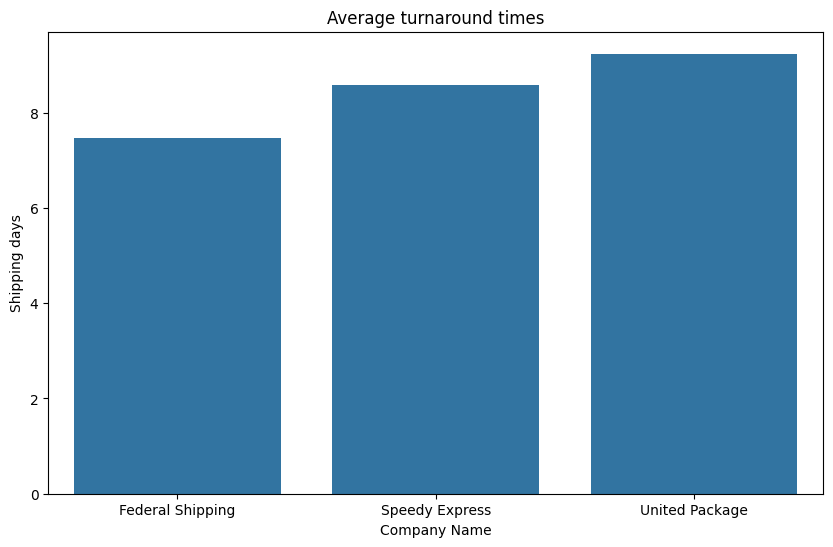

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_shipping_sorted, x='CompanyName', y='ShippingDays')

plt.title('Average turnaround times')
plt.xlabel('Company Name')
plt.ylabel('Shipping days')
plt.show()